In [ ]:
import pandas as pd
df = pd.read_csv('/content/customer_churn_data.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,CUST0000,Male,0,No,Yes,23,No,No phone service,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer,49.85,1146.55,No
1,CUST0001,Female,0,Yes,No,43,No,No phone service,DSL,Yes,...,Yes,No,Yes,No,Month-to-month,No,Mailed check,100.70,4330.10,Yes
2,CUST0002,Male,1,No,No,51,Yes,No,DSL,No,...,Yes,Yes,No,No,One year,No,Electronic check,97.33,4963.83,Yes
3,CUST0003,Male,1,No,No,72,Yes,Yes,DSL,Yes,...,Yes,No,No,No,Month-to-month,No,Credit card,101.38,7299.36,No
4,CUST0004,Male,1,No,No,25,Yes,Yes,DSL,No,...,No,Yes,No,Yes,Month-to-month,No,Electronic check,52.22,1305.50,Yes


In [ ]:
print("Checking for duplicate rows:")
duplicate_rows = df.duplicated().sum()
if duplicate_rows > 0:
    print(f"Found {duplicate_rows} duplicate rows.")
else:
    print("No duplicate rows found.")

print("\nChecking for null values before filling:")
initial_null_counts = df.isnull().sum()
display(initial_null_counts[initial_null_counts > 0])
df.fillna('NA', inplace=True)
print("\nChecking for null values after filling with 'NA':")
final_null_counts = df.isnull().sum()
display(final_null_counts[final_null_counts > 0])
print("\nUpdated DataFrame head after handling nulls:")
display(df.head())

Checking for duplicate rows:
No duplicate rows found.

Checking for null values before filling:


,0



Checking for null values after filling with 'NA':


,0



Updated DataFrame head after handling nulls:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,CUST0000,Male,0,No,Yes,23,No,No phone service,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer,49.85,1146.55,No
1,CUST0001,Female,0,Yes,No,43,No,No phone service,DSL,Yes,...,Yes,No,Yes,No,Month-to-month,No,Mailed check,100.70,4330.10,Yes
2,CUST0002,Male,1,No,No,51,Yes,No,DSL,No,...,Yes,Yes,No,No,One year,No,Electronic check,97.33,4963.83,Yes
3,CUST0003,Male,1,No,No,72,Yes,Yes,DSL,Yes,...,Yes,No,No,No,Month-to-month,No,Credit card,101.38,7299.36,No
4,CUST0004,Male,1,No,No,25,Yes,Yes,DSL,No,...,No,Yes,No,Yes,Month-to-month,No,Electronic check,52.22,1305.50,Yes


## **Exploratory Data Analysis (EDA)**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import pandas as pd
df = pd.read_csv('/content/customer_churn_data.csv')
df['Churn_numeric'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(0, inplace=True)
df['SeniorCitizen_label'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})
print("Data types after initial preprocessing:")
display(df[['Churn', 'Churn_numeric', 'TotalCharges', 'SeniorCitizen', 'SeniorCitizen_label']].info())
display(df.head())

Data types after initial preprocessing:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5880 entries, 0 to 5879
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Churn                5880 non-null   object 
 1   Churn_numeric        5880 non-null   int64  
 2   TotalCharges         5880 non-null   float64
 3   SeniorCitizen        5880 non-null   int64  
 4   SeniorCitizen_label  5880 non-null   object 
dtypes: float64(1), int64(2), object(2)
memory usage: 229.8+ KB


/tmp/ipykernel_9536/4100811470.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(0, inplace=True)


None

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_numeric,SeniorCitizen_label
0,CUST0000,Male,0,No,Yes,23,No,No phone service,No,No internet service,...,No internet service,No internet service,Month-to-month,Yes,Bank transfer,49.85,1146.55,No,0,No
1,CUST0001,Female,0,Yes,No,43,No,No phone service,DSL,Yes,...,Yes,No,Month-to-month,No,Mailed check,100.70,4330.10,Yes,1,No
2,CUST0002,Male,1,No,No,51,Yes,No,DSL,No,...,No,No,One year,No,Electronic check,97.33,4963.83,Yes,1,Yes
3,CUST0003,Male,1,No,No,72,Yes,Yes,DSL,Yes,...,No,No,Month-to-month,No,Credit card,101.38,7299.36,No,0,Yes
4,CUST0004,Male,1,No,No,25,Yes,Yes,DSL,No,...,No,Yes,Month-to-month,No,Electronic check,52.22,1305.50,Yes,1,Yes


/tmp/ipykernel_9536/4081360884.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_counts.index, y=churn_counts.values, palette='viridis')


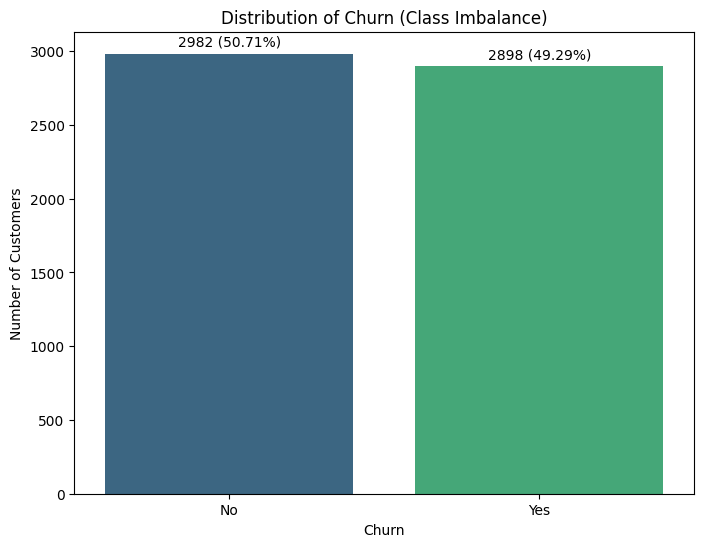

In [ ]:
churn_counts = df['Churn'].value_counts()
churn_percentage = df['Churn'].value_counts(normalize=True) * 100
plt.figure(figsize=(8, 6))
sns.barplot(x=churn_counts.index, y=churn_counts.values, palette='viridis')
plt.title('Distribution of Churn (Class Imbalance)')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
for index, value in enumerate(churn_counts.values):
    plt.text(index, value + 50, f'{value} ({churn_percentage.iloc[index]:.2f}%)', ha='center')
plt.show()

Churn rate by Senior Citizen status:


,SeniorCitizen_label,Churn_numeric,Churn_percentage
0,No,0.495232,49.523161
1,Yes,0.490489,49.048913


/tmp/ipykernel_9536/2536132356.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='SeniorCitizen_label', y='Churn_percentage', data=churn_by_senior_citizen, palette='coolwarm')


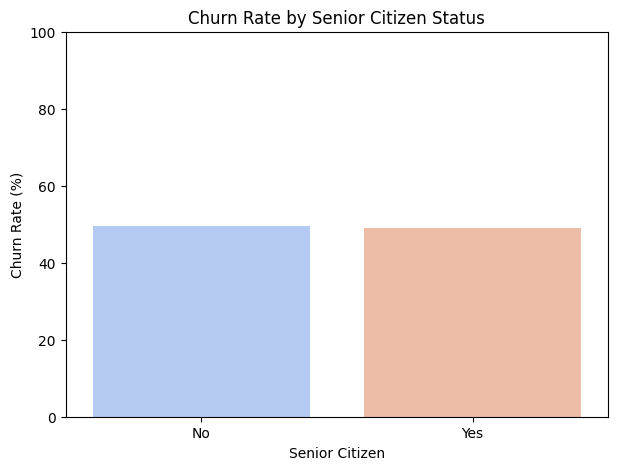

In [ ]:
churn_by_senior_citizen = df.groupby('SeniorCitizen_label')['Churn_numeric'].mean().reset_index()
churn_by_senior_citizen['Churn_percentage'] = churn_by_senior_citizen['Churn_numeric'] * 100
print("Churn rate by Senior Citizen status:")
display(churn_by_senior_citizen)
plt.figure(figsize=(7, 5))
sns.barplot(x='SeniorCitizen_label', y='Churn_percentage', data=churn_by_senior_citizen, palette='coolwarm')
plt.title('Churn Rate by Senior Citizen Status')
plt.xlabel('Senior Citizen')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, 100)
plt.show()

/tmp/ipykernel_9536/1558843996.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tenure', data=df, palette='pastel')


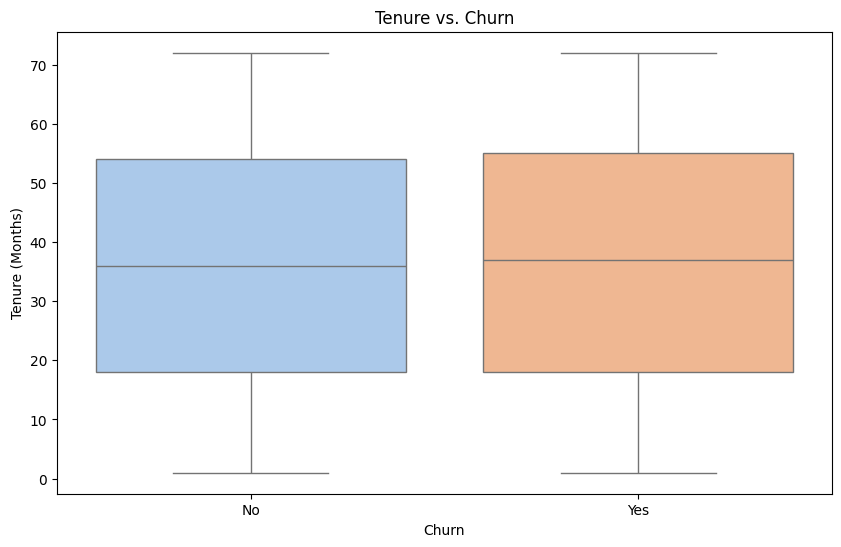

Churn rate by Tenure Group:


,tenure_group,Churn_numeric,Churn_percentage
0,0-12 Months,0.475560,47.556008
1,13-24 Months,0.496565,49.656526
2,25-48 Months,0.504509,50.450928
3,49-60 Months,0.475904,47.590361
4,61+ Months,0.501002,50.100200


/tmp/ipykernel_9536/1558843996.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='tenure_group', y='Churn_percentage', data=churn_by_tenure_group, palette='magma')


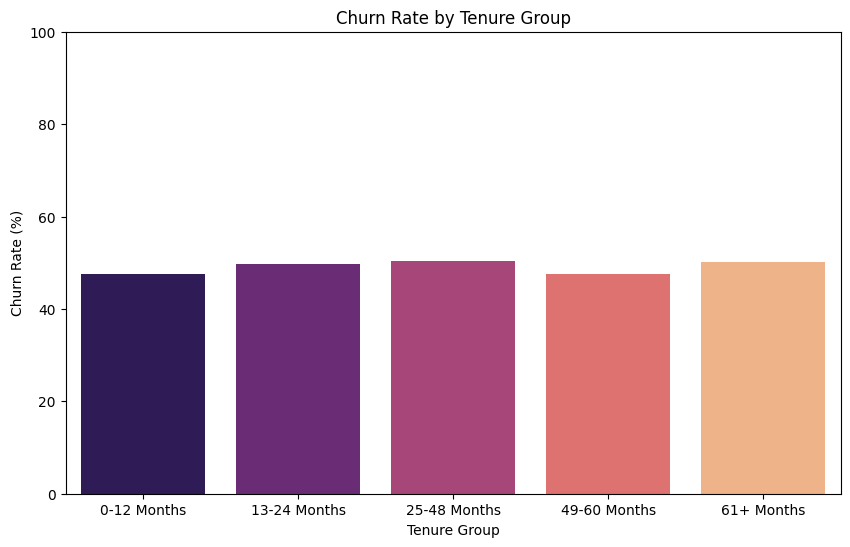

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Churn', y='tenure', data=df, palette='pastel')
plt.title('Tenure vs. Churn')
plt.xlabel('Churn')
plt.ylabel('Tenure (Months)')
plt.show()
def tenure_band(row):
    if row['tenure'] <= 12: return '0-12 Months'
    elif row['tenure'] <= 24: return '13-24 Months'
    elif row['tenure'] <= 48: return '25-48 Months'
    elif row['tenure'] <= 60: return '49-60 Months'
    else: return '61+ Months'

df['tenure_group'] = df.apply(tenure_band, axis=1)

churn_by_tenure_group = df.groupby('tenure_group')['Churn_numeric'].mean().reset_index()
churn_by_tenure_group['Churn_percentage'] = churn_by_tenure_group['Churn_numeric'] * 100
tenure_order = ['0-12 Months', '13-24 Months', '25-48 Months', '49-60 Months', '61+ Months']
churn_by_tenure_group['tenure_group'] = pd.Categorical(churn_by_tenure_group['tenure_group'], categories=tenure_order, ordered=True)
churn_by_tenure_group = churn_by_tenure_group.sort_values('tenure_group')

print("Churn rate by Tenure Group:")
display(churn_by_tenure_group)

plt.figure(figsize=(10, 6))
sns.barplot(x='tenure_group', y='Churn_percentage', data=churn_by_tenure_group, palette='magma')
plt.title('Churn Rate by Tenure Group')
plt.xlabel('Tenure Group')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, 100)
plt.show()

Churn rate by Contract Type:


,Contract,Churn_numeric,Churn_percentage
0,Month-to-month,0.477228,47.722772
1,One year,0.504606,50.460594
2,Two year,0.497377,49.737671


/tmp/ipykernel_9536/1903101637.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Contract', y='Churn_percentage', data=churn_by_contract, palette='cividis')


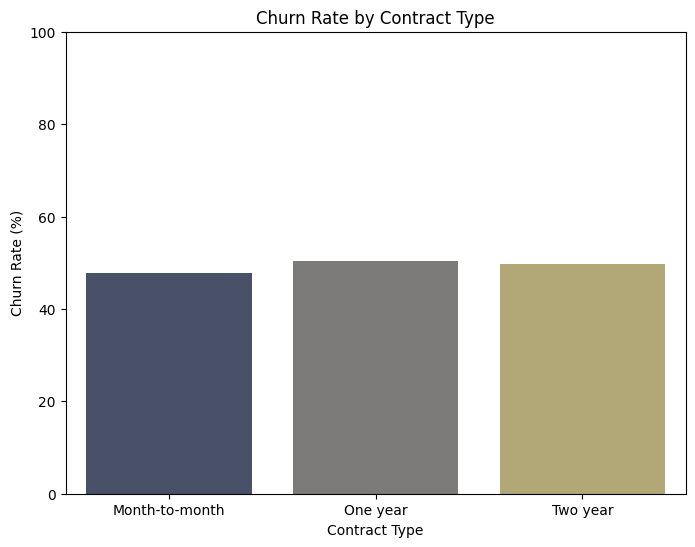

In [ ]:
churn_by_contract = df.groupby('Contract')['Churn_numeric'].mean().reset_index()
churn_by_contract['Churn_percentage'] = churn_by_contract['Churn_numeric'] * 100

print("Churn rate by Contract Type:")
display(churn_by_contract)

plt.figure(figsize=(8, 6))
sns.barplot(x='Contract', y='Churn_percentage', data=churn_by_contract, palette='cividis')
plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, 100)
plt.show()

/tmp/ipykernel_9536/2731546606.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='viridis')


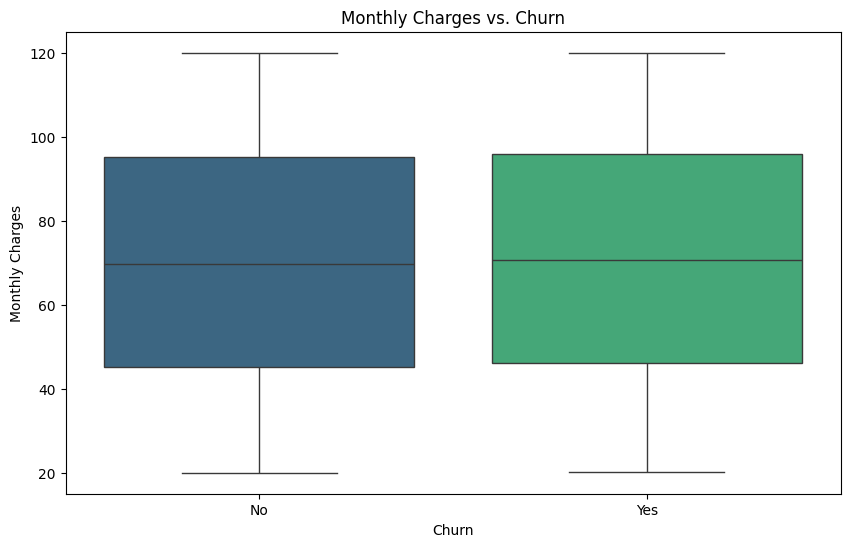

Churn rate by Monthly Charges Group:


,MonthlyCharges_group,Churn_numeric,Churn_percentage
1,Low (<25),0.430464,43.046358
2,Medium (25-50),0.496847,49.684653
0,High (50-75),0.493005,49.300466
3,Very High (>75),0.497736,49.773585


/tmp/ipykernel_9536/2731546606.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='MonthlyCharges_group', y='Churn_percentage', data=churn_by_monthly_charges_group, palette='plasma')


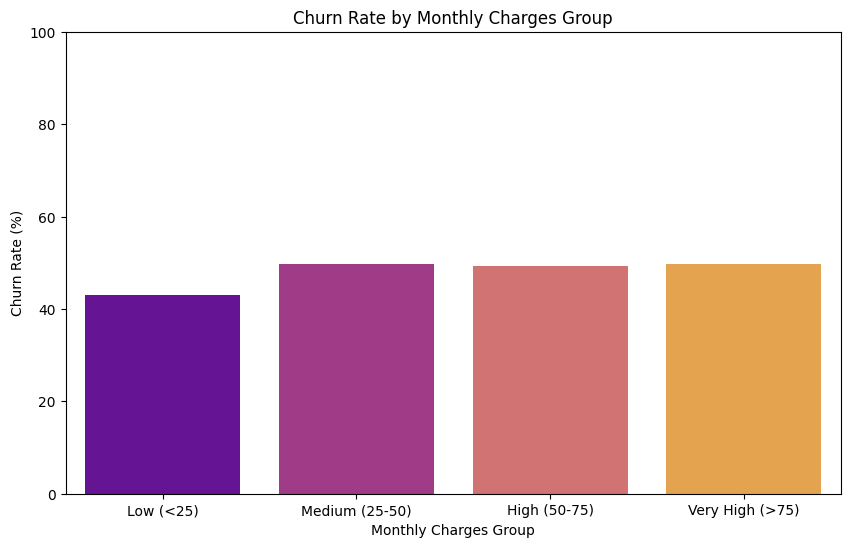

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='viridis')
plt.title('Monthly Charges vs. Churn')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')
plt.show()
def monthly_charges_band(row):
    if row['MonthlyCharges'] <= 25: return 'Low (<25)'
    elif row['MonthlyCharges'] <= 50: return 'Medium (25-50)'
    elif row['MonthlyCharges'] <= 75: return 'High (50-75)'
    else: return 'Very High (>75)'
df['MonthlyCharges_group'] = df.apply(monthly_charges_band, axis=1)
churn_by_monthly_charges_group = df.groupby('MonthlyCharges_group')['Churn_numeric'].mean().reset_index()
churn_by_monthly_charges_group['Churn_percentage'] = churn_by_monthly_charges_group['Churn_numeric'] * 100
charges_order = ['Low (<25)', 'Medium (25-50)', 'High (50-75)', 'Very High (>75)']
churn_by_monthly_charges_group['MonthlyCharges_group'] = pd.Categorical(churn_by_monthly_charges_group['MonthlyCharges_group'], categories=charges_order, ordered=True)
churn_by_monthly_charges_group = churn_by_monthly_charges_group.sort_values('MonthlyCharges_group')

print("Churn rate by Monthly Charges Group:")
display(churn_by_monthly_charges_group)

plt.figure(figsize=(10, 6))
sns.barplot(x='MonthlyCharges_group', y='Churn_percentage', data=churn_by_monthly_charges_group, palette='plasma')
plt.title('Churn Rate by Monthly Charges Group')
plt.xlabel('Monthly Charges Group')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, 100)
plt.show()

/tmp/ipykernel_9536/2168642091.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='Churn_percentage', data=churn_by_service, palette='crest')
/tmp/ipykernel_9536/2168642091.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='Churn_percentage', data=churn_by_service, palette='crest')
/tmp/ipykernel_9536/2168642091.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='Churn_percentage', data=churn_by_service, palette='crest')
/tmp/ipykernel_9536/2168642091.py:12: FutureWarning: 

Passing `palette` without assigni

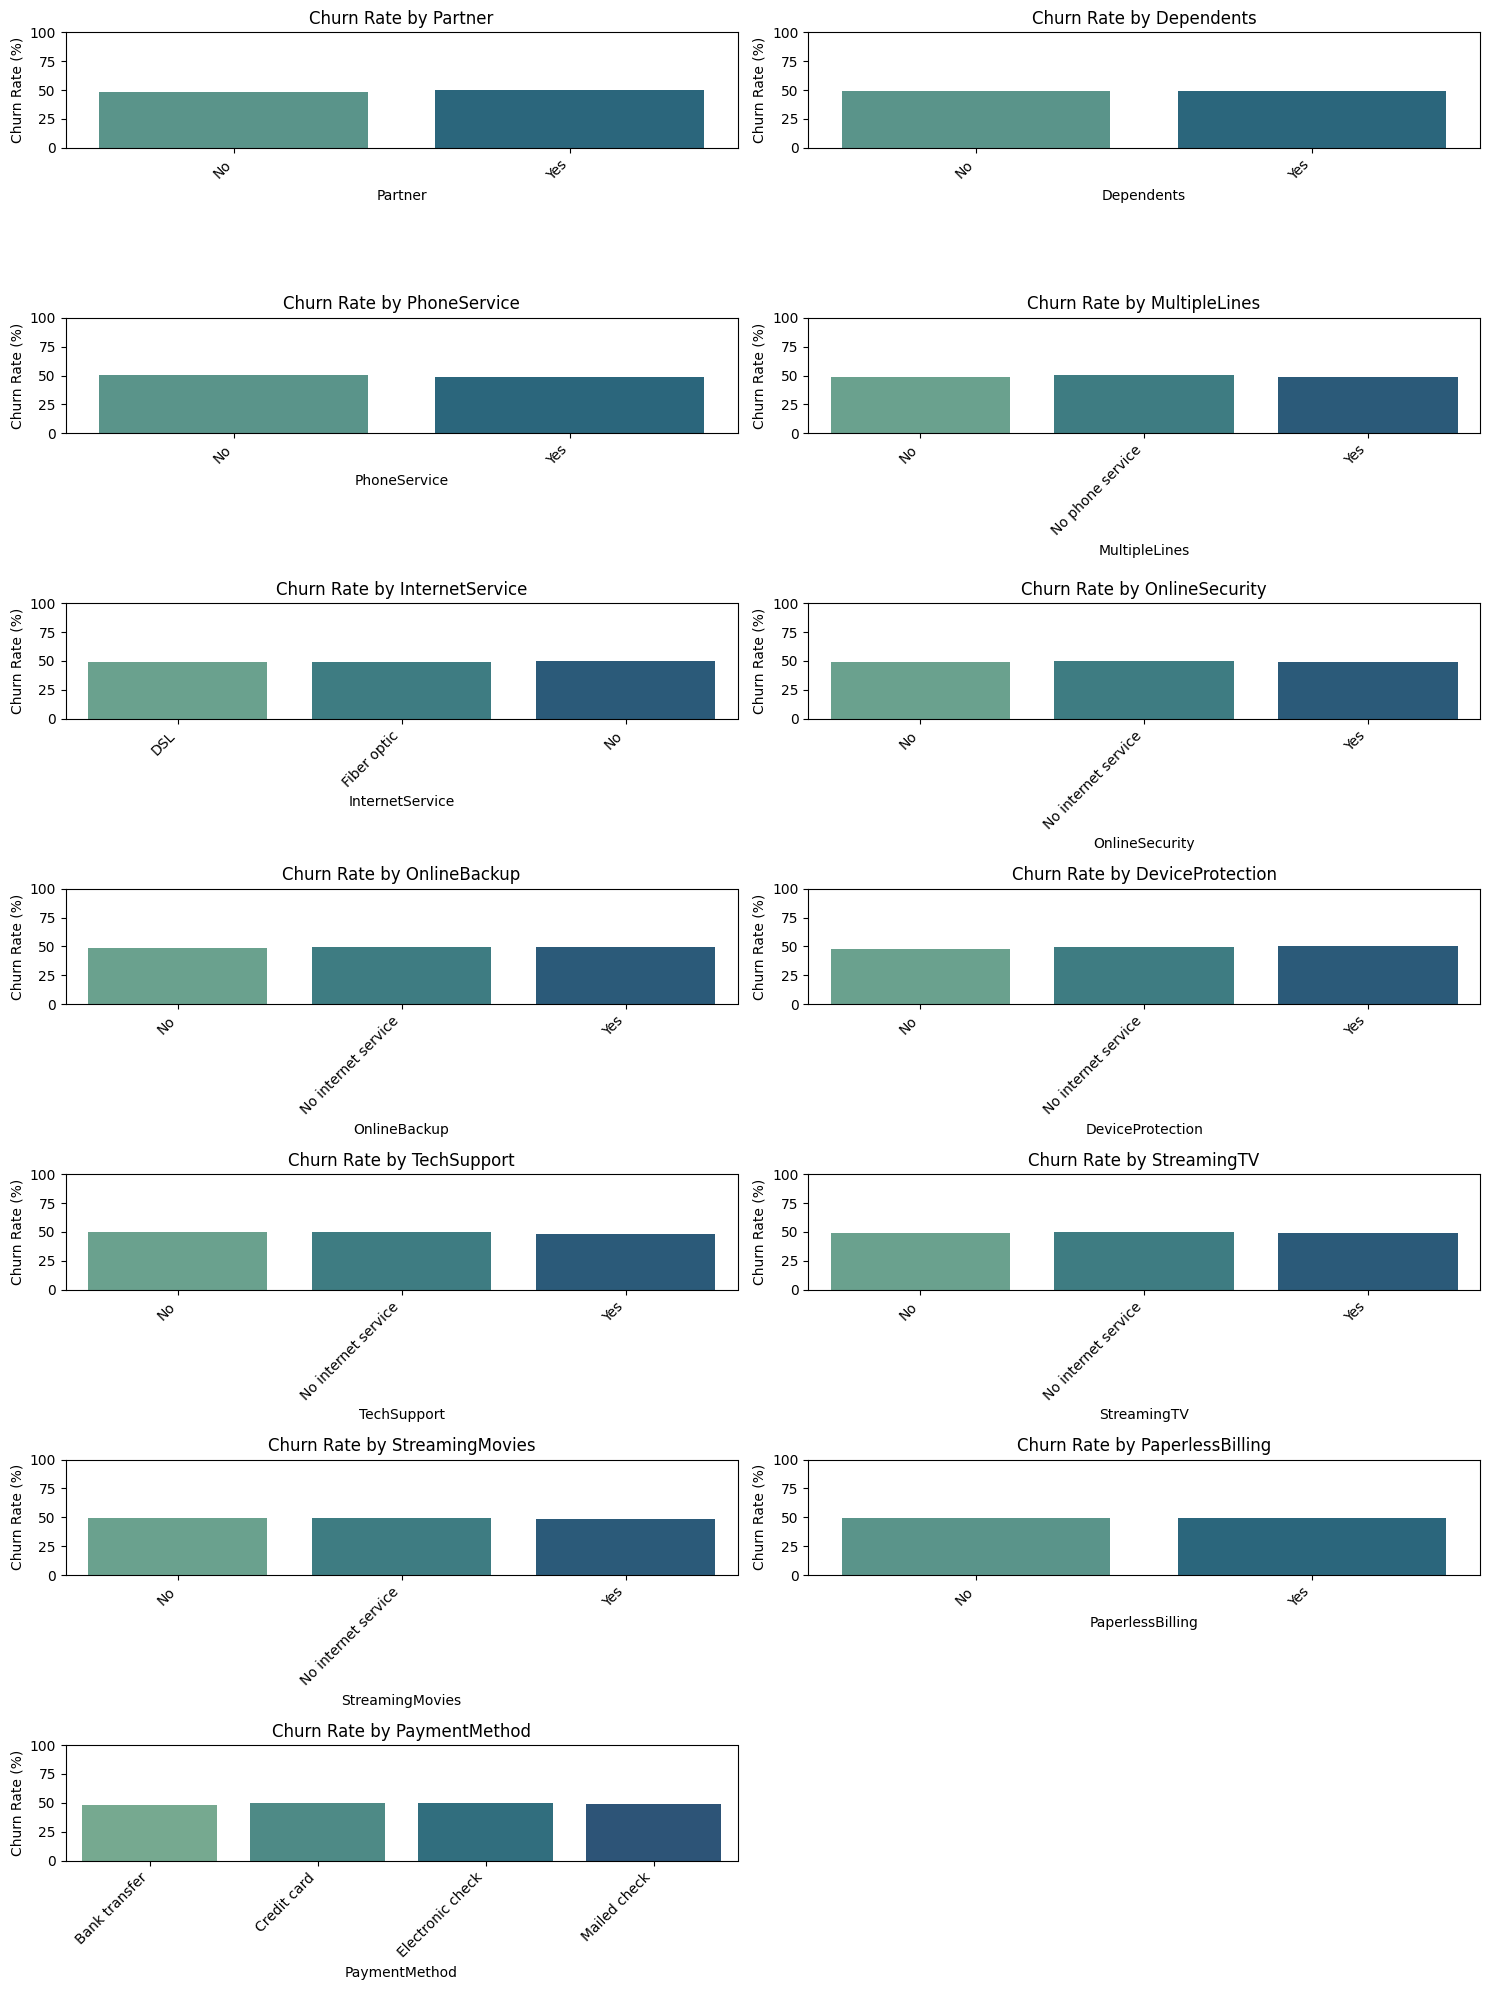


Churn rate by Internet Service:


,InternetService,Churn_numeric,Churn_percentage
0,DSL,0.490186,49.018595
1,Fiber optic,0.491384,49.138381
2,No,0.496796,49.679645


/tmp/ipykernel_9536/2168642091.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='InternetService', y='Churn_percentage', data=churn_by_internet_service, palette='mako')


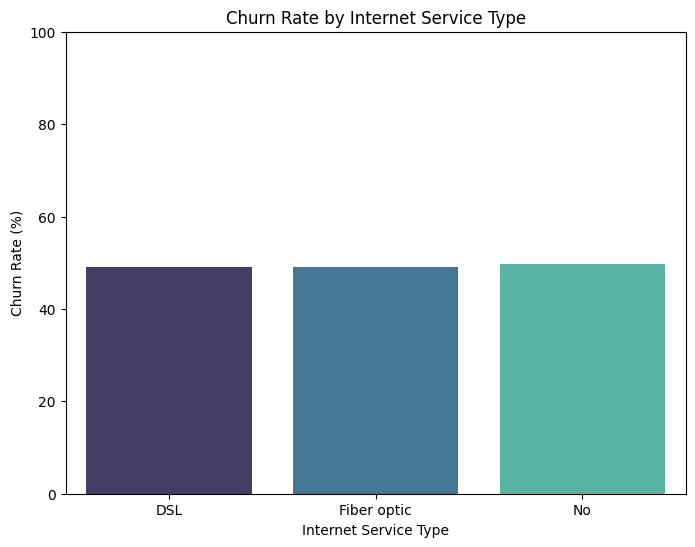

In [ ]:
service_columns = [
    'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'PaymentMethod'
]

plt.figure(figsize=(15, 20))
for i, col in enumerate(service_columns, 1):
    plt.subplot(len(service_columns)//2 + 1, 2, i)
    churn_by_service = df.groupby(col)['Churn_numeric'].mean().reset_index()
    churn_by_service['Churn_percentage'] = churn_by_service['Churn_numeric'] * 100
    sns.barplot(x=col, y='Churn_percentage', data=churn_by_service, palette='crest')
    plt.title(f'Churn Rate by {col}')
    plt.xlabel(col)
    plt.ylabel('Churn Rate (%)')
    plt.ylim(0, 100)
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
churn_by_internet_service = df.groupby('InternetService')['Churn_numeric'].mean().reset_index()
churn_by_internet_service['Churn_percentage'] = churn_by_internet_service['Churn_numeric'] * 100

print("\nChurn rate by Internet Service:")
display(churn_by_internet_service)

plt.figure(figsize=(8, 6))
sns.barplot(x='InternetService', y='Churn_percentage', data=churn_by_internet_service, palette='mako')
plt.title('Churn Rate by Internet Service Type')
plt.xlabel('Internet Service Type')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, 100)
plt.show()

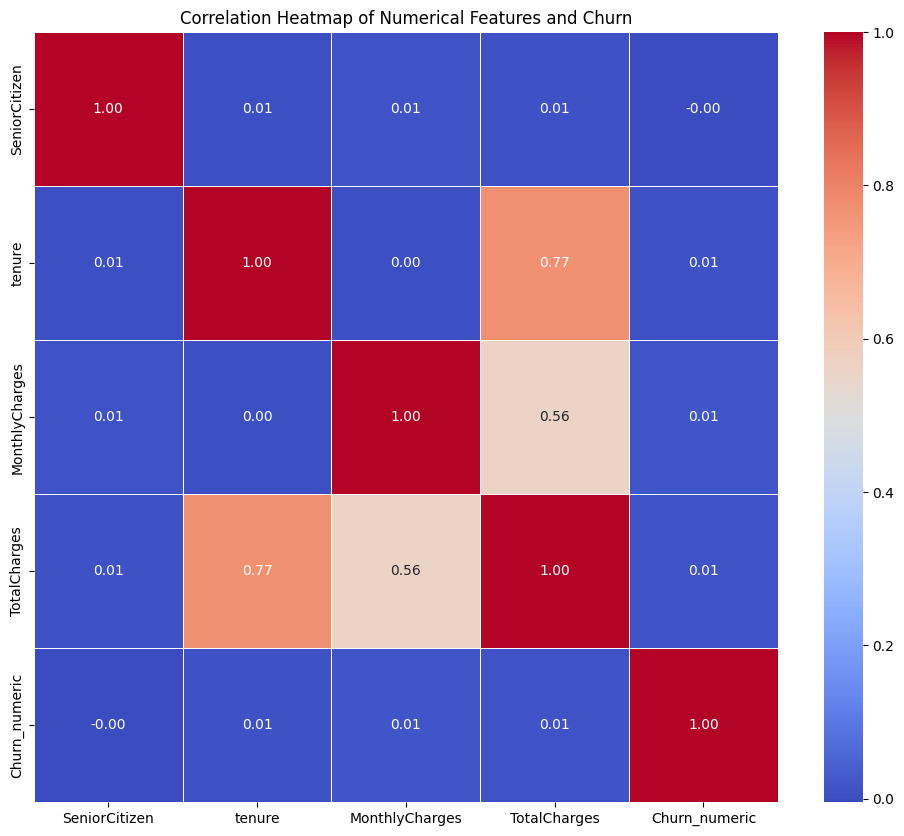


Correlation of features with Churn (including encoded categorical variables):


,Churn_numeric
Churn_numeric,1.000000
MultipleLines_No phone service,0.018024
Contract_One year,0.016579
MonthlyCharges,0.014969
TotalCharges,0.014264
DeviceProtection_Yes,0.011421
Partner_Yes,0.010134
tenure,0.008600
gender_Male,0.008213
PaymentMethod_Credit card,0.007202


In [ ]:
numerical_df = df.select_dtypes(include=[np.number])
correlation_matrix = numerical_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features and Churn')
plt.show()
df_encoded = df.drop(columns=['customerID', 'SeniorCitizen', 'Churn', 'SeniorCitizen_label', 'tenure_group', 'MonthlyCharges_group'])
df_encoded = pd.get_dummies(df_encoded, drop_first=True)
correlation_matrix_full = df_encoded.corr()
churn_correlations = correlation_matrix_full['Churn_numeric'].sort_values(ascending=False)

print("\nCorrelation of features with Churn (including encoded categorical variables):")
display(churn_correlations)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(0, inplace=True)
X = df.drop(columns=['customerID', 'Churn', 'Churn_numeric', 'SeniorCitizen_label', 'tenure_group', 'MonthlyCharges_group'])
y = df['Churn_numeric']

print("Original features shape:", X.shape)
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_cols = X.select_dtypes(include='object').columns.tolist() + ['SeniorCitizen']
numerical_cols = [col for col in numerical_cols if col not in categorical_cols]
X_categorical = pd.get_dummies(X[categorical_cols], drop_first=True)
scaler = StandardScaler()
X_numerical_scaled = scaler.fit_transform(X[numerical_cols])
X_numerical_scaled = pd.DataFrame(X_numerical_scaled, columns=numerical_cols, index=X.index)
X_processed = pd.concat([X_numerical_scaled, X_categorical], axis=1)

print("Processed features shape after encoding and scaling:", X_processed.shape)
X_train, X_temp, y_train, y_temp = train_test_split(X_processed, y, test_size=0.2, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print("\nDataset Split Shapes:")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

display(X_processed.head())

Original features shape: (5880, 19)
Processed features shape after encoding and scaling: (5880, 30)

Dataset Split Shapes:
X_train shape: (4704, 30), y_train shape: (4704,)
X_val shape: (588, 30), y_val shape: (588,)
X_test shape: (588, 30), y_test shape: (588,)


/tmp/ipykernel_9536/1901588321.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(0, inplace=True)


,tenure,MonthlyCharges,TotalCharges,SeniorCitizen,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card,PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,-0.648040,-0.705078,-0.743650,0,True,False,True,False,True,False,...,True,False,True,False,False,False,True,False,False,False
1,0.308537,1.060414,0.923257,0,False,True,False,False,True,False,...,False,True,False,False,False,False,False,False,False,True
2,0.691167,0.943409,1.255078,1,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,True,False
3,1.695572,1.084023,2.477961,1,True,False,False,True,False,True,...,False,False,False,False,False,False,False,True,False,False
4,-0.552382,-0.622793,-0.660423,1,True,False,False,True,False,True,...,False,False,False,True,False,False,False,False,True,False


In [ ]:
cleaned_df = X_processed.copy()
cleaned_df['Churn_numeric'] = y.values
output_filename = 'customer_churn_cleaned.csv'
cleaned_df.to_csv(output_filename, index=False)

print(f"Cleaned data saved successfully as '{output_filename}'")

Cleaned data saved successfully as 'customer_churn_cleaned.csv'


In [ ]:
print("\n--- Feature Engineering ---")
df['AvgMonthlySpend'] = df.apply(lambda row: row['TotalCharges'] / row['tenure'] if row['tenure'] > 0 else 0, axis=1)
print("Created 'AvgMonthlySpend' feature.")
def create_tenure_bucket(tenure):
    if tenure <= 12: return 'New'
    elif tenure <= 48: return 'Medium'
    else: return 'Loyal'
df['Tenure_Bucket'] = df['tenure'].apply(create_tenure_bucket)
print("Created 'Tenure_Bucket' feature.")
service_cols = [
    'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]
temp_df = df[service_cols].replace({'No internet service': 'No', 'No phone service': 'No'})
df['Service_Count'] = (temp_df == 'Yes').sum(axis=1)
print("Created 'Service_Count' feature.")
df['Contract_Month_to_Month'] = (df['Contract'] == 'Month-to-month').astype(int)
df['Contract_One_Year'] = (df['Contract'] == 'One year').astype(int)
df['Contract_Two_Year'] = (df['Contract'] == 'Two year').astype(int)
print("Created 'Contract_Month_to_Month', 'Contract_One_Year', 'Contract_Two_Year' flags.")
total_charges_threshold = df['TotalCharges'].quantile(0.75)
tenure_threshold = df['tenure'].quantile(0.75)

df['High_Value_Customer'] = ((df['TotalCharges'] >= total_charges_threshold) & (df['tenure'] >= tenure_threshold)).astype(int)
print("Created 'High_Value_Customer' feature.")

print("\nDataFrame head with new features:")
display(df[['customerID', 'tenure', 'TotalCharges', 'MonthlyCharges', 'AvgMonthlySpend', 'Tenure_Bucket', 'Service_Count', 'Contract_Month_to_Month', 'Contract_One_Year', 'Contract_Two_Year', 'High_Value_Customer', 'Churn_numeric']].head())


--- Feature Engineering ---
Created 'AvgMonthlySpend' feature.
Created 'Tenure_Bucket' feature.
Created 'Service_Count' feature.
Created 'Contract_Month_to_Month', 'Contract_One_Year', 'Contract_Two_Year' flags.
Created 'High_Value_Customer' feature.

DataFrame head with new features:


,customerID,tenure,TotalCharges,MonthlyCharges,AvgMonthlySpend,Tenure_Bucket,Service_Count,Contract_Month_to_Month,Contract_One_Year,Contract_Two_Year,High_Value_Customer,Churn_numeric
0,CUST0000,23,1146.55,49.85,49.85,Medium,0,1,0,0,0,0
1,CUST0001,43,4330.10,100.70,100.70,Medium,3,1,0,0,0,1
2,CUST0002,51,4963.83,97.33,97.33,Loyal,4,0,1,0,0,1
3,CUST0003,72,7299.36,101.38,101.38,Loyal,4,1,0,0,1,0
4,CUST0004,25,1305.50,52.22,52.22,Medium,4,1,0,0,0,1


--- Model Evaluation (Validation Set) ---
Precision: 0.4621
Recall:    0.4207
F1-Score:  0.4404
ROC-AUC:   0.4902

Classification Report:
              precision    recall  f1-score   support

           0       0.48      0.52      0.50       298
           1       0.46      0.42      0.44       290

    accuracy                           0.47       588
   macro avg       0.47      0.47      0.47       588
weighted avg       0.47      0.47      0.47       588



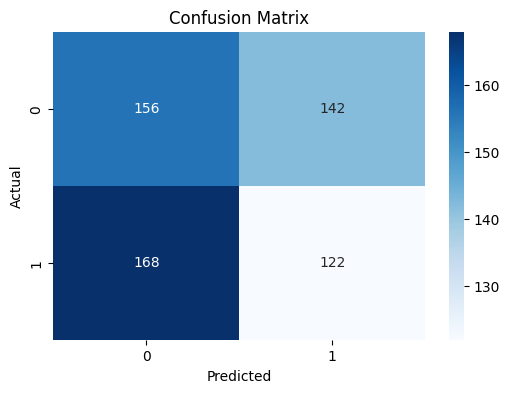

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix
model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)
y_pred = model.fit(X_train, y_train).predict(X_val)
y_probs = model.predict_proba(X_val)[:, 1]
precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)
roc_auc = roc_auc_score(y_val, y_probs)

print("--- Model Evaluation (Validation Set) ---")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_val, y_pred))
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_val, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

--- Logistic Regression Baseline: Classification Report ---
              precision    recall  f1-score   support

           0       0.48      0.47      0.48       298
           1       0.47      0.48      0.48       290

    accuracy                           0.48       588
   macro avg       0.48      0.48      0.48       588
weighted avg       0.48      0.48      0.48       588



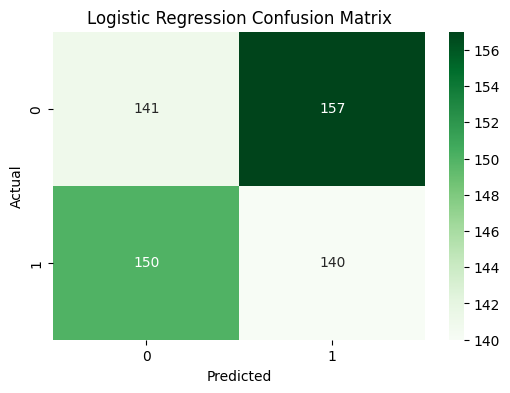

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_val)
print("--- Logistic Regression Baseline: Classification Report ---")
print(classification_report(y_val, y_pred_log))
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_val, y_pred_log), annot=True, fmt='d', cmap='Greens')
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

--- Gradient Boosting Classifier ---
              precision    recall  f1-score   support

           0       0.49      0.49      0.49       298
           1       0.47      0.48      0.48       290

    accuracy                           0.48       588
   macro avg       0.48      0.48      0.48       588
weighted avg       0.48      0.48      0.48       588



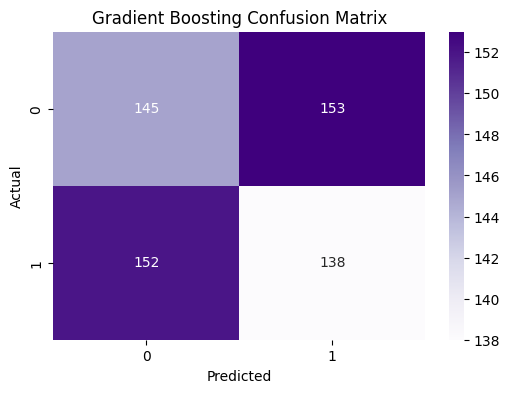


--- XGBoost Classifier ---
              precision    recall  f1-score   support

           0       0.47      0.41      0.44       298
           1       0.46      0.52      0.49       290

    accuracy                           0.46       588
   macro avg       0.46      0.46      0.46       588
weighted avg       0.46      0.46      0.46       588



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:23:54] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


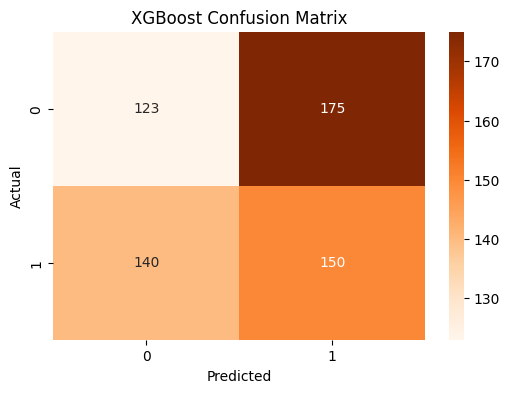

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
print("--- Gradient Boosting Classifier ---")
gbc = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gbc.fit(X_train, y_train)
y_pred_gbc = gbc.predict(X_val)
print(classification_report(y_val, y_pred_gbc))
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_val, y_pred_gbc), annot=True, fmt='d', cmap='Purples')
plt.title('Gradient Boosting Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
print("\n--- XGBoost Classifier ---")
ratio = (y_train == 0).sum() / (y_train == 1).sum()
xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, scale_pos_weight=ratio, random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_val)
print(classification_report(y_val, y_pred_xgb))
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_val, y_pred_xgb), annot=True, fmt='d', cmap='Oranges')
plt.title('XGBoost Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
import pickle
from google.colab import files
files_to_download = {
    'logistic_regression_baseline.pkl': log_reg,
    'random_forest_model.pkl': model,
    'gradient_boosting_model.pkl': gbc,
    'xgb_churn_model.pkl': xgb,
    'scaler.pkl': scaler
}
for filename, model_obj in files_to_download.items():
    with open(filename, 'wb') as f:
        pickle.dump(model_obj, f)
    print(f"Saved: {filename}")
for filename in files_to_download.keys():
    files.download(filename)

Saved: logistic_regression_baseline.pkl
Saved: random_forest_model.pkl
Saved: gradient_boosting_model.pkl
Saved: xgb_churn_model.pkl
Saved: scaler.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

--- Threshold Optimization ---
Cost of losing a customer: $500
Cost of retention incentive: $50
Optimal Threshold: 0.25
Minimum Business Cost at this threshold: $14850


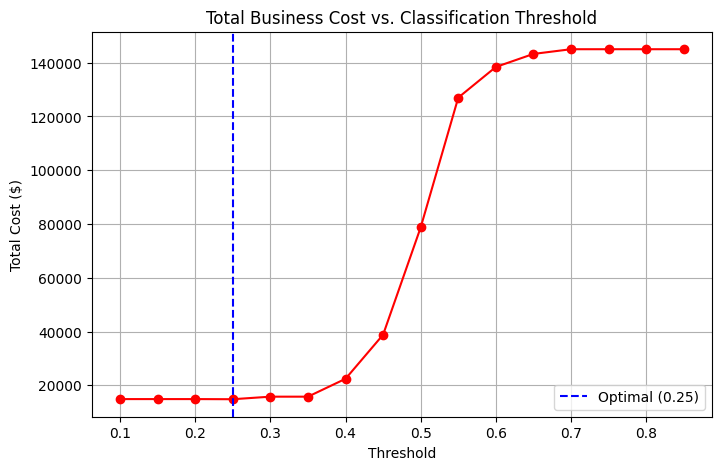

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix
cost_losing_customer = 500
cost_retention_incentive = 50

y_probs_xgb = xgb.predict_proba(X_val)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.05)
costs = []

for t in thresholds:
    y_pred_t = (y_probs_xgb >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred_t).ravel()

    total_cost = (fn * cost_losing_customer) + (fp * cost_retention_incentive)
    costs.append(total_cost)
optimal_idx = np.argmin(costs)
optimal_threshold = thresholds[optimal_idx]
min_cost = costs[optimal_idx]

print(f"--- Threshold Optimization ---")
print(f"Cost of losing a customer: ${cost_losing_customer}")
print(f"Cost of retention incentive: ${cost_retention_incentive}")
print(f"Optimal Threshold: {optimal_threshold:.2f}")
print(f"Minimum Business Cost at this threshold: ${min_cost}")
plt.figure(figsize=(8, 5))
plt.plot(thresholds, costs, marker='o', color='red')
plt.axvline(optimal_threshold, color='blue', linestyle='--', label=f'Optimal ({optimal_threshold:.2f})')
plt.title('Total Business Cost vs. Classification Threshold')
plt.xlabel('Threshold')
plt.ylabel('Total Cost ($)')
plt.legend()
plt.grid(True)
plt.show()

--- SHAP Global Feature Importance ---


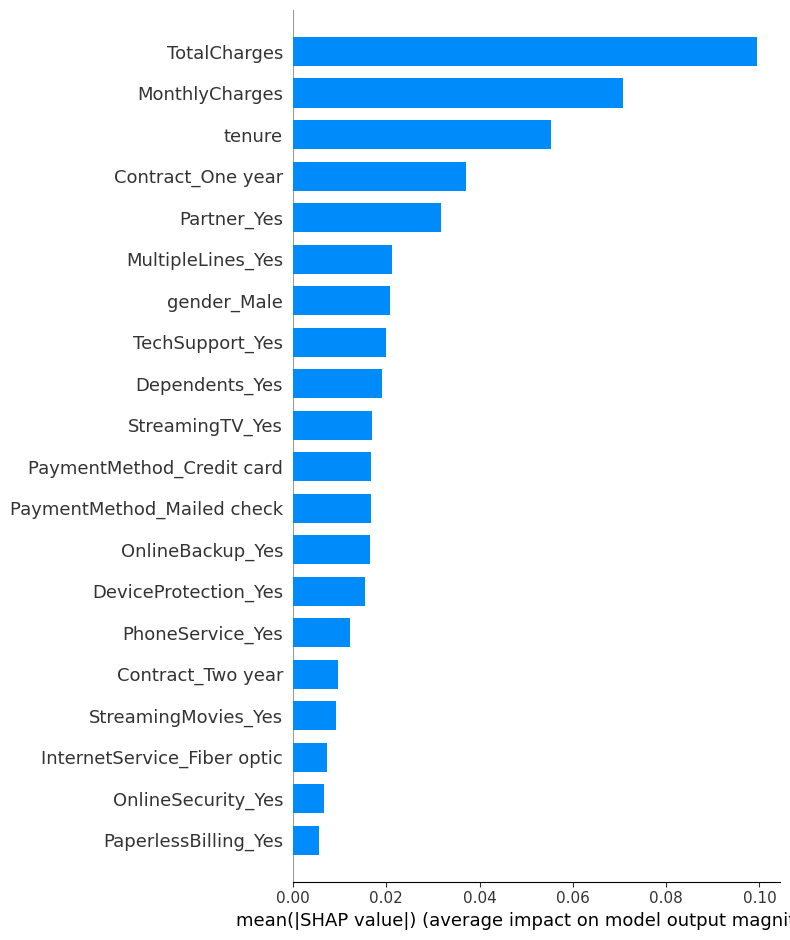

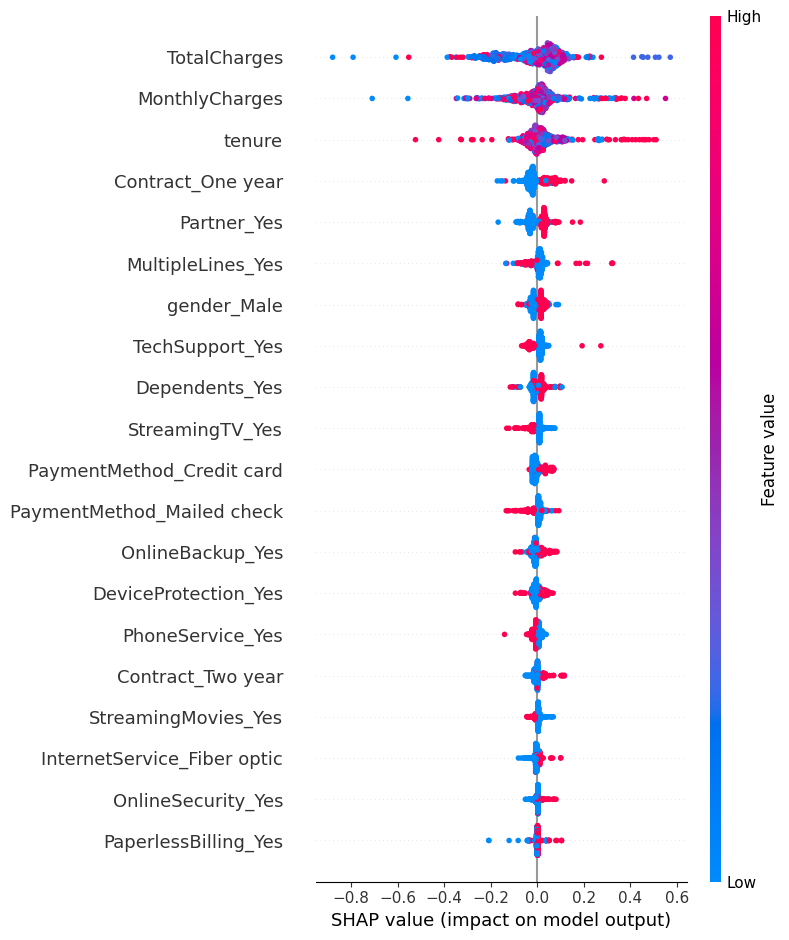


--- SHAP Local Explanation (First Customer in Validation Set) ---


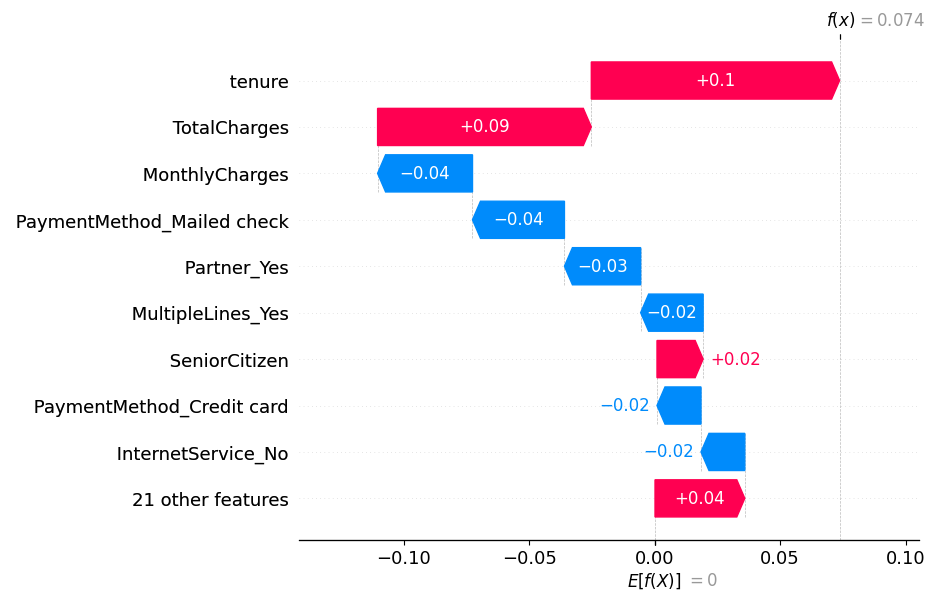


--- Explanation ---
• Why customers churn: Features pushing the SHAP value to the right (positive) increase churn probability.
• Top Drivers: Features at the top of the bar chart are the most influential across the entire dataset.


In [ ]:
!pip install shap -q
import shap
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_val)
print("--- SHAP Global Feature Importance ---")
shap.summary_plot(shap_values, X_val, plot_type="bar")
shap.summary_plot(shap_values, X_val)
print("\n--- SHAP Local Explanation (First Customer in Validation Set) ---")
customer_index = 0
shap.initjs()
shap.plots._waterfall.waterfall_legacy(explainer.expected_value, shap_values[customer_index], X_val.iloc[customer_index])

print("\n--- Explanation ---")
print("• Why customers churn: Features pushing the SHAP value to the right (positive) increase churn probability.")
print("• Top Drivers: Features at the top of the bar chart are the most influential across the entire dataset.")

In [ ]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 77.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 106.2 MB/s eta 0:00:00


In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import pickle
import numpy as np
st.set_page_config(page_title="Customer Churn Predictor", layout="wide")
FEATURES = [
    'tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen',
    'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
    'MultipleLines_No phone service', 'MultipleLines_Yes',
    'InternetService_Fiber optic', 'InternetService_No',
    'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
    'OnlineBackup_No internet service', 'OnlineBackup_Yes',
    'DeviceProtection_No internet service', 'DeviceProtection_Yes',
    'TechSupport_No internet service', 'TechSupport_Yes',
    'StreamingTV_No internet service', 'StreamingTV_Yes',
    'StreamingMovies_No internet service', 'StreamingMovies_Yes',
    'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
    'PaymentMethod_Credit card', 'PaymentMethod_Electronic check',
    'PaymentMethod_Mailed check'
]

@st.cache_resource
def load_models():
    """Load all available model files."""
    models = {
        "Random Forest": "random_forest_model.pkl",
        "Gradient Boosting": "gradient_boosting_model.pkl",
        "XGBoost": "xgb_churn_model.pkl",
        "Logistic Regression": "logistic_regression_baseline.pkl"
    }
    loaded_models = {}
    for name, path in models.items():
        try:
            with open(path, 'rb') as f:
                loaded_models[name] = pickle.load(f)
        except FileNotFoundError:
            st.warning(f"Model file {path} not found.")
    try:
        with open('scaler.pkl', 'rb') as f:
            scaler = pickle.load(f)
    except FileNotFoundError:
        scaler = None
        st.warning("Scaler file not found. Ensure features are pre-scaled.")

    return loaded_models, scaler

models, scaler = load_models()

st.title("📊 Customer Churn Prediction & Analysis")
st.markdown("""
Predicts customer churn, explains the likelihood, and helps drive retention actions.
""")
st.sidebar.header("Model Settings")
selected_model_name = st.sidebar.selectbox("Select Model", list(models.keys()))
model = models.get(selected_model_name)

st.sidebar.header("Customer Information")
def user_input_features():
    tenure = st.sidebar.slider('Tenure (Months)', 0, 72, 24)
    monthly_charges = st.sidebar.number_input('Monthly Charges', 0.0, 150.0, 70.0)
    total_charges = st.sidebar.number_input('Total Charges', 0.0, 10000.0, 1500.0)

    senior = 1 if st.sidebar.checkbox('Senior Citizen') else 0
    gender = 1 if st.sidebar.selectbox('Gender', ['Female', 'Male']) == 'Male' else 0
    partner = 1 if st.sidebar.checkbox('Has Partner') else 0
    dependents = 1 if st.sidebar.checkbox('Has Dependents') else 0
    data = pd.DataFrame(np.zeros((1, len(FEATURES))), columns=FEATURES)
    data['tenure'] = tenure
    data['MonthlyCharges'] = monthly_charges
    data['TotalCharges'] = total_charges
    data['SeniorCitizen'] = senior
    data['gender_Male'] = gender
    data['Partner_Yes'] = partner
    data['Dependents_Yes'] = dependents

    return data

input_df = user_input_features()
if model is not None:
    st.header("Prediction Results")
    st.subheader("Customer Information")
    st.write(input_df)
    processed_df = input_df.copy()
    if scaler and selected_model_name == "Logistic Regression":
        processed_df[['tenure', 'MonthlyCharges', 'TotalCharges']] = scaler.transform(
            input_df[['tenure', 'MonthlyCharges', 'TotalCharges']]
        )
    prediction = model.predict(processed_df)
    prediction_proba = model.predict_proba(processed_df)

    col1, col2 = st.columns(2)

    with col1:
        st.subheader("Churn Prediction")
        if prediction[0] == 1:
            st.error("⚠️ Customer is likely to CHURN")
        else:
            st.success("✅ Customer is likely to STAY")

        st.metric("Churn Probability", f"{prediction_proba[0][1]:.2%}")

    with col2:
        st.subheader("Why is the customer churning?")
        if hasattr(model, 'feature_importances_'):
            importances = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=False).head(5)
            st.bar_chart(importances)
            st.info("Top factors influencing this model's decision are shown above.")
        else:
            st.write("Feature importance analysis is limited for this model type.")
    st.divider()
    st.subheader("💡 Recommended Retention Actions")
    if prediction[0] == 1:
        if input_df['tenure'][0] < 12:
            st.markdown("- **Onboarding Support:** This new customer may need more guidance on service value.")
        if input_df['MonthlyCharges'][0] > 80:
            st.markdown("- **Discount Offer:** High monthly costs detected; consider a loyalty discount.")
        st.markdown("- **Feedback Loop:** Reach out for a satisfaction survey immediately.")
    else:
        st.markdown("- **Upsell Opportunity:** Customer is stable; consider introducing premium features.")

else:
    st.error("Model could not be loaded. Please check your .pkl files.")

Writing app.py


In [ ]:
!pip install -q streamlit
!wget https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared-linux-amd64
import subprocess
subprocess.Popen(["./cloudflared-linux-amd64", "tunnel", "--url", "http://localhost:8501"])
!nohup /content/cloudflared-linux-amd64 tunnel --url http://localhost:8501 &

--2026-04-12 09:24:13--  https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
Resolving github.com (github.com)... 140.82.116.3
Connecting to github.com (github.com)|140.82.116.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/cloudflare/cloudflared/releases/download/2026.3.0/cloudflared-linux-amd64 [following]
--2026-04-12 09:24:13--  https://github.com/cloudflare/cloudflared/releases/download/2026.3.0/cloudflared-linux-amd64
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/106867604/731ab2f8-6b77-4adb-a7b3-1104525e9d72?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-04-12T10%3A03%3A45Z&rscd=attachment%3B+filename%3Dcloudflared-linux-amd64&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-04-12T0

In [ ]:
!streamlit run /content/app.py &>/content/logs.txt &

In [ ]:
!grep -o 'https://.*\.trycloudflare.com' nohup.out | head -n 1 | xargs -I {} echo "Your tunnel url {}"

Your tunnel url https://drivers-gonna-explore-kilometers.trycloudflare.com
